In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

### Part G

In [15]:
def generate_data(N, beta, sigma2, a, b, model_type="censored"):
    beta = np.array(beta)
    sigma = np.sqrt(sigma2)
    
    # Generate X: column of 1s and standard normal
    X = np.column_stack([np.ones(N), np.random.randn(N)])
    
    # Generate true Y
    Y = X @ beta + sigma * np.random.randn(N)
    
    if model_type == "censored":
        # Censor observations
        W = Y.copy()
        W[Y <= a] = a
        W[Y >= b] = b
        return W, X
    
    elif model_type == "truncated":
        # Keep only observations in (a, b)
        mask = (Y > a) & (Y < b)
        W = Y[mask]
        X_truncated = X[mask]
        return W, X_truncated
    
    else:
        raise ValueError("model_type must be 'censored' or 'truncated'")

### Part H

Fraction censored from below: 0.2051
Fraction censored from above: 0.2072


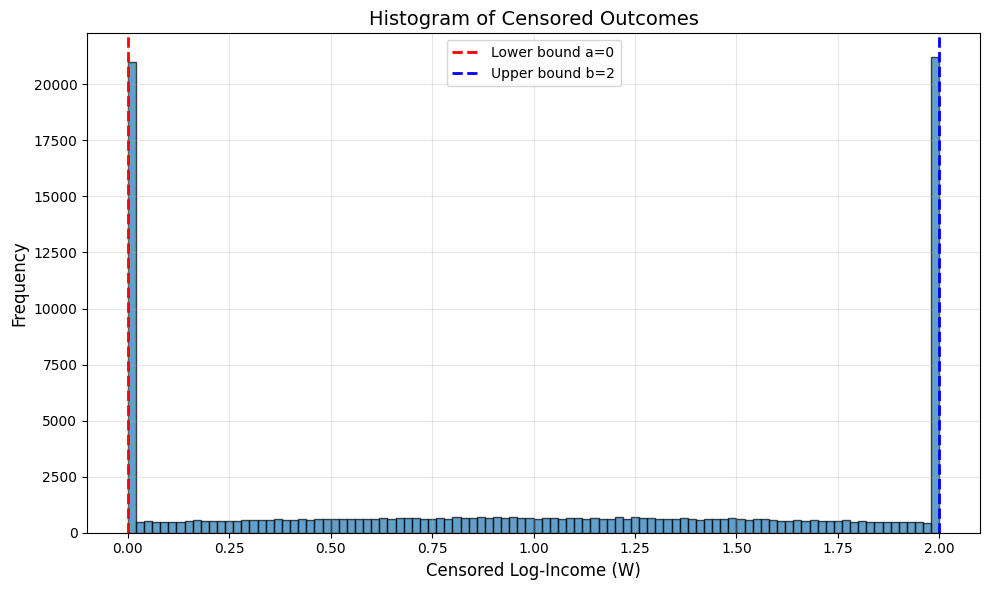

In [16]:
# Generate censored data
beta = np.array([1.0, 0.7])
N = 100000
a = 0
b = 2
sigma2 = 1.0

W_censored, X_censored = generate_data(N, beta, sigma2, a, b, model_type="censored")

# Calculate fractions censored
frac_below = np.mean(W_censored == a)
frac_above = np.mean(W_censored == b)

print(f"Fraction censored from below: {frac_below:.4f}")
print(f"Fraction censored from above: {frac_above:.4f}")

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(W_censored, bins=100, edgecolor='black', alpha=0.7)
plt.axvline(a, color='red', linestyle='--', linewidth=2, label=f'Lower bound a={a}')
plt.axvline(b, color='blue', linestyle='--', linewidth=2, label=f'Upper bound b={b}')
plt.xlabel('Censored Log-Income (W)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Censored Outcomes', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Part I


True values: Intercept=1.0000, Slope=0.7000
Mean estimates: Intercept=1.0002, Slope=0.4113
Bias: Intercept=0.0002, Slope=-0.2887


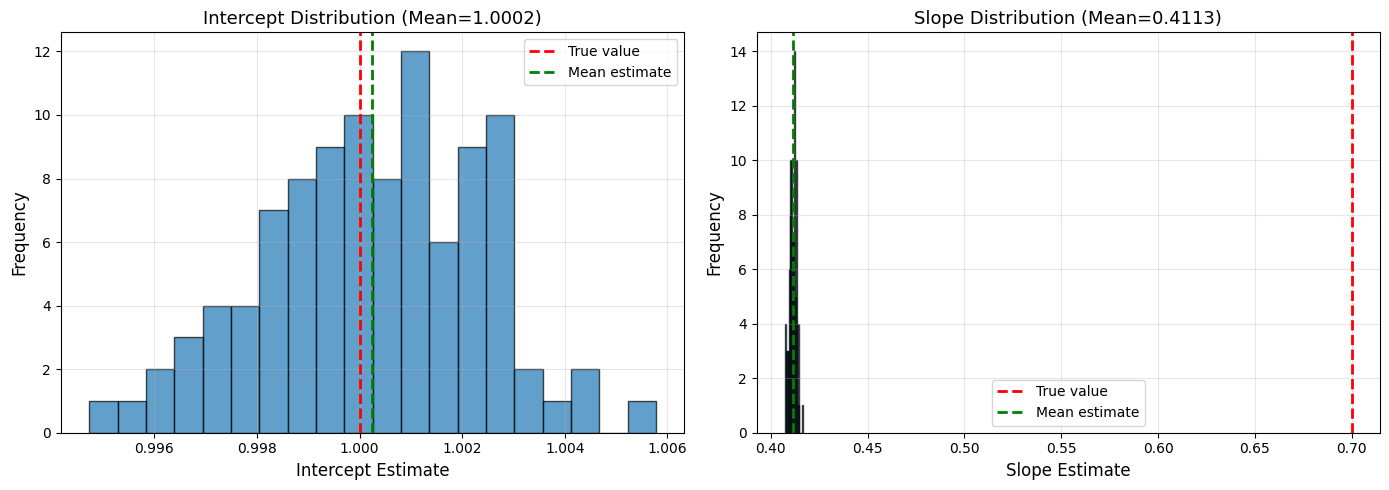

In [17]:
# Run S simulations
S = 100
beta_estimates = np.zeros((S, 2))

np.random.seed(123)
for s in range(S):
    W_sim, X_sim = generate_data(N, beta, sigma2, a, b, model_type="censored")
    # OLS: beta_hat = (X'X)^{-1} X'W
    beta_estimates[s] = np.linalg.lstsq(X_sim, W_sim, rcond=None)[0]

# Calculate means
mean_intercept = np.mean(beta_estimates[:, 0])
mean_slope = np.mean(beta_estimates[:, 1])

print(f"\nTrue values: Intercept={beta[0]:.4f}, Slope={beta[1]:.4f}")
print(f"Mean estimates: Intercept={mean_intercept:.4f}, Slope={mean_slope:.4f}")
print(f"Bias: Intercept={mean_intercept - beta[0]:.4f}, Slope={mean_slope - beta[1]:.4f}")

# Plot histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(beta_estimates[:, 0], bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(beta[0], color='red', linestyle='--', linewidth=2, label='True value')
axes[0].axvline(mean_intercept, color='green', linestyle='--', linewidth=2, label='Mean estimate')
axes[0].set_xlabel('Intercept Estimate', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title(f'Intercept Distribution (Mean={mean_intercept:.4f})', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(beta_estimates[:, 1], bins=20, edgecolor='black', alpha=0.7)
axes[1].axvline(beta[1], color='red', linestyle='--', linewidth=2, label='True value')
axes[1].axvline(mean_slope, color='green', linestyle='--', linewidth=2, label='Mean estimate')
axes[1].set_xlabel('Slope Estimate', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title(f'Slope Distribution (Mean={mean_slope:.4f})', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Part J


Truncated dataset size: 51616 (started with 100000)
Fraction kept: 0.5162


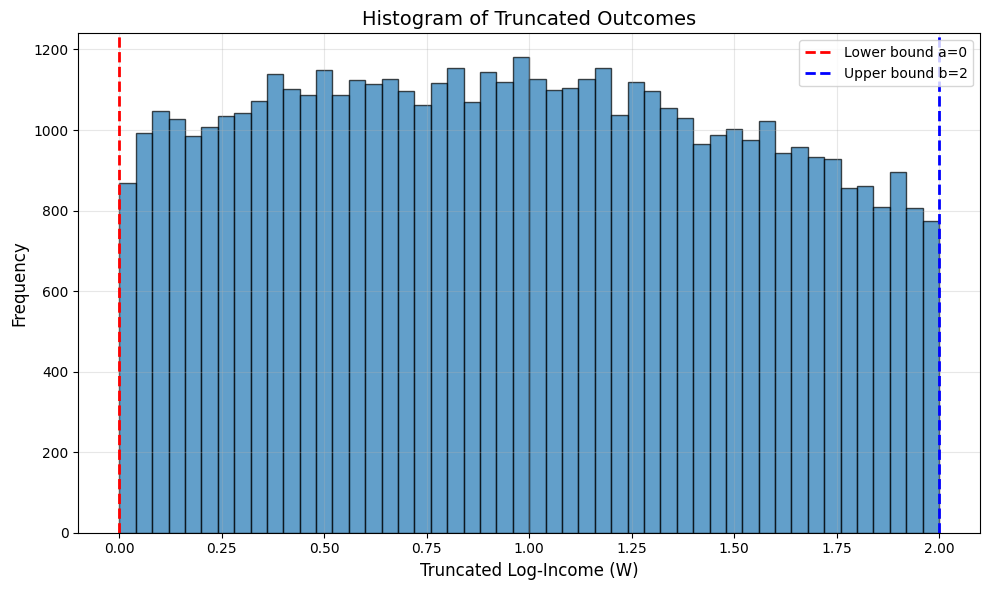


From the dataset alone, you CANNOT tell what fraction was truncated
because the truncated observations are completely omitted from the data.


In [18]:
# Generate truncated data
beta_trunc = np.array([0.8, 1.0])
np.random.seed(42)

W_truncated, X_truncated = generate_data(N, beta_trunc, sigma2, a, b, model_type="truncated")

print(f"\nTruncated dataset size: {len(W_truncated)} (started with {N})")
print(f"Fraction kept: {len(W_truncated)/N:.4f}")

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(W_truncated, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(a, color='red', linestyle='--', linewidth=2, label=f'Lower bound a={a}')
plt.axvline(b, color='blue', linestyle='--', linewidth=2, label=f'Upper bound b={b}')
plt.xlabel('Truncated Log-Income (W)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of Truncated Outcomes', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFrom the dataset alone, you CANNOT tell what fraction was truncated")
print("because the truncated observations are completely omitted from the data.")

### Part K


True values: Intercept=0.8000, Slope=1.0000
Mean estimates: Intercept=0.9463, Slope=0.2694
Bias: Intercept=0.1463, Slope=-0.7306


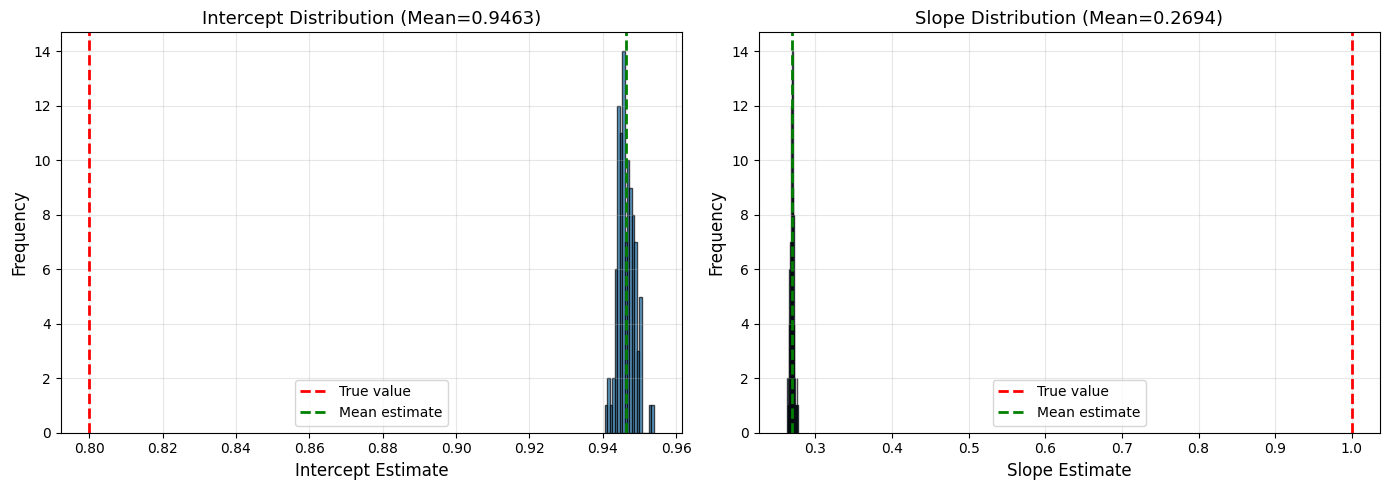

In [19]:
# Run S simulations with truncated data
S = 100
beta_estimates_trunc = np.zeros((S, 2))

np.random.seed(456)
for s in range(S):
    W_sim, X_sim = generate_data(N, beta_trunc, sigma2, a, b, model_type="truncated")
    beta_estimates_trunc[s] = np.linalg.lstsq(X_sim, W_sim, rcond=None)[0]

# Calculate means
mean_intercept_trunc = np.mean(beta_estimates_trunc[:, 0])
mean_slope_trunc = np.mean(beta_estimates_trunc[:, 1])

print(f"\nTrue values: Intercept={beta_trunc[0]:.4f}, Slope={beta_trunc[1]:.4f}")
print(f"Mean estimates: Intercept={mean_intercept_trunc:.4f}, Slope={mean_slope_trunc:.4f}")
print(f"Bias: Intercept={mean_intercept_trunc - beta_trunc[0]:.4f}, Slope={mean_slope_trunc - beta_trunc[1]:.4f}")

# Plot histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(beta_estimates_trunc[:, 0], bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(beta_trunc[0], color='red', linestyle='--', linewidth=2, label='True value')
axes[0].axvline(mean_intercept_trunc, color='green', linestyle='--', linewidth=2, label='Mean estimate')
axes[0].set_xlabel('Intercept Estimate', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title(f'Intercept Distribution (Mean={mean_intercept_trunc:.4f})', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(beta_estimates_trunc[:, 1], bins=20, edgecolor='black', alpha=0.7)
axes[1].axvline(beta_trunc[1], color='red', linestyle='--', linewidth=2, label='True value')
axes[1].axvline(mean_slope_trunc, color='green', linestyle='--', linewidth=2, label='Mean estimate')
axes[1].set_xlabel('Slope Estimate', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title(f'Slope Distribution (Mean={mean_slope_trunc:.4f})', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Part M

In [20]:
def false_truncated_loglik(params, W, X, a, b):
    beta = params[:-1]
    sigma2 = params[-1]
    sigma = np.sqrt(sigma2)
    
    # Compute residuals
    residuals = W - X @ beta
    
    # Log-likelihood (just the normal density, no truncation adjustment)
    loglik = -0.5 * np.log(2 * np.pi) - np.log(sigma) - 0.5 * (residuals**2) / sigma2
    
    return np.sum(loglik)

### Part N

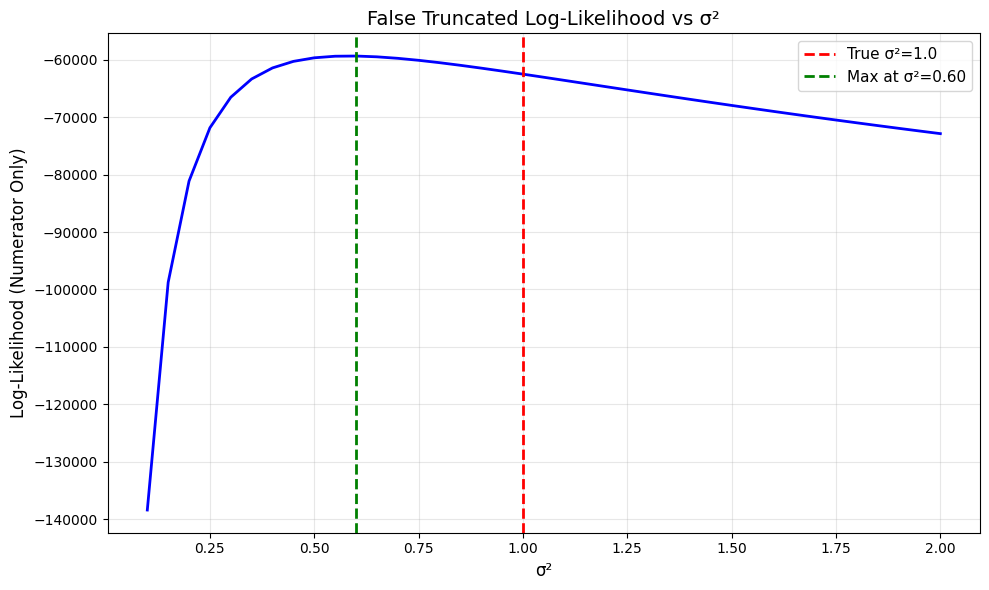


Maximum false log-likelihood at σ² = 0.60
True σ² = 1.0


In [21]:
# Use truncated dataset from part (j)
# True beta_trunc = [0.8, 1.0], sigma2 = 1.0

sigma2_grid = np.arange(0.1, 2.05, 0.05)
loglik_values = np.zeros(len(sigma2_grid))

for i, sig2 in enumerate(sigma2_grid):
    params = np.concatenate([beta_trunc, [sig2]])
    loglik_values[i] = false_truncated_loglik(params, W_truncated, X_truncated, a, b)

# Find maximum
max_idx = np.argmax(loglik_values)
max_sigma2 = sigma2_grid[max_idx]

plt.figure(figsize=(10, 6))
plt.plot(sigma2_grid, loglik_values, 'b-', linewidth=2)
plt.axvline(1.0, color='red', linestyle='--', linewidth=2, label='True σ²=1.0')
plt.axvline(max_sigma2, color='green', linestyle='--', linewidth=2, 
            label=f'Max at σ²={max_sigma2:.2f}')
plt.xlabel('σ²', fontsize=12)
plt.ylabel('Log-Likelihood (Numerator Only)', fontsize=12)
plt.title('False Truncated Log-Likelihood vs σ²', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMaximum false log-likelihood at σ² = {max_sigma2:.2f}")
print(f"True σ² = 1.0")

### Part O

The false log-likelihood (using only the numerator) is maximized at a σ² value smaller than the true value. This occurs because:

- Truncation creates a restricted sample: The truncated data only includes observations where b < y_i < a, which systematically excludes extreme values from both tails.
- The observed variance is artificially reduced: Looking at the histogram from part (j), the truncated sample has observations concentrated in the middle of the distribution (between 0 and 2), with no extreme values.
- Without the denominator correction: The standard normal likelihood just tries to match the sample variance of the truncated data, which is smaller than the true population variance.
- The missing normalization: The denominator P(b < Y < a) would account for the fact that we're conditioning on being in the truncated range. Without it, the MLE incorrectly attributes the reduced spread entirely to a smaller σ².

### Part P

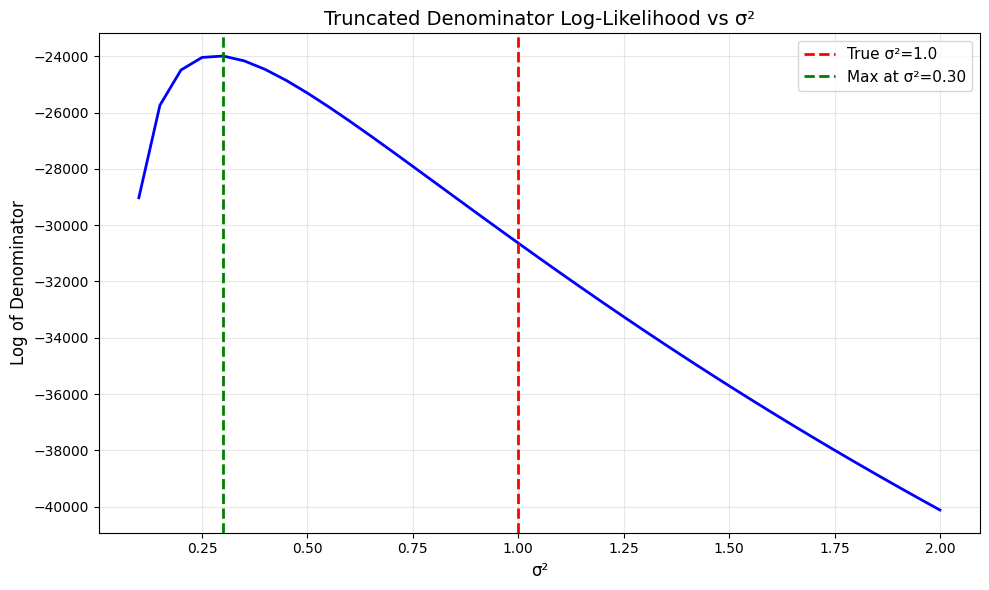


Maximum denominator at σ² = 0.30
True σ² = 1.0


In [22]:
def denominator_loglik(params, W, X, a, b):
    beta = params[:-1]
    sigma2 = params[-1]
    sigma = np.sqrt(sigma2)
    
    # Compute truncation probabilities for each observation
    prob_above_a = norm.cdf((X @ beta - a) / sigma)
    prob_below_b = norm.cdf((b - X @ beta) / sigma)
    
    # P(a < Y < b) = P(Y < b) - P(Y <= a)
    truncation_prob = prob_below_b - (1 - prob_above_a)
    
    # Log of denominator (sum over all observations)
    log_denominator = np.sum(np.log(truncation_prob))
    
    return log_denominator

# Plot denominator log-likelihood
denom_values = np.zeros(len(sigma2_grid))

for i, sig2 in enumerate(sigma2_grid):
    params = np.concatenate([beta_trunc, [sig2]])
    denom_values[i] = denominator_loglik(params, W_truncated, X_truncated, a, b)

# Find maximum
max_idx_denom = np.argmax(denom_values)
max_sigma2_denom = sigma2_grid[max_idx_denom]

plt.figure(figsize=(10, 6))
plt.plot(sigma2_grid, denom_values, 'b-', linewidth=2)
plt.axvline(1.0, color='red', linestyle='--', linewidth=2, label='True σ²=1.0')
plt.axvline(max_sigma2_denom, color='green', linestyle='--', linewidth=2, 
            label=f'Max at σ²={max_sigma2_denom:.2f}')
plt.xlabel('σ²', fontsize=12)
plt.ylabel('Log of Denominator', fontsize=12)
plt.title('Truncated Denominator Log-Likelihood vs σ²', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMaximum denominator at σ² = {max_sigma2_denom:.2f}")
print(f"True σ² = 1.0")

### Part Q

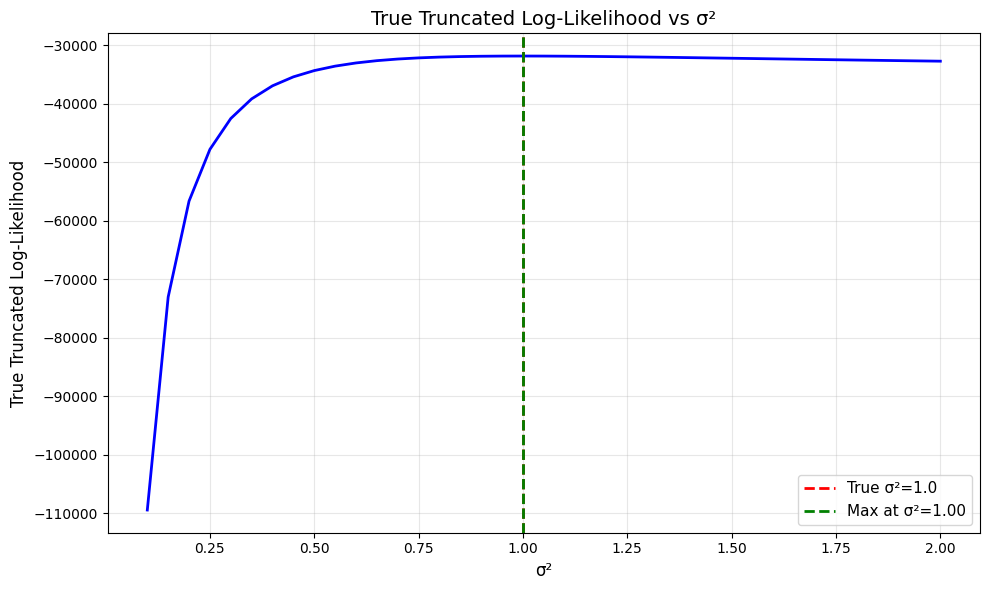


Maximum true log-likelihood at σ² = 1.00
True σ² = 1.0


In [23]:
def true_truncated_loglik(params, W, X, a, b):
    """
    Compute true truncated log-likelihood (numerator - denominator).
    """
    beta = params[:-1]
    sigma2 = params[-1]
    sigma = np.sqrt(sigma2)
    
    # Numerator: normal density
    residuals = W - X @ beta
    numerator = -0.5 * np.log(2 * np.pi) - np.log(sigma) - 0.5 * (residuals**2) / sigma2
    
    # Denominator: truncation probability
    upper_std = (b - X @ beta) / sigma
    lower_std = (a - X @ beta) / sigma
    truncation_prob = norm.cdf(upper_std) - norm.cdf(lower_std)
    
    # Avoid log(0)
    truncation_prob = np.maximum(truncation_prob, 1e-10)
    denominator = np.log(truncation_prob)
    
    # True log-likelihood
    loglik = numerator - denominator
    
    return np.sum(loglik)

# Plot true truncated log-likelihood
true_loglik_values = np.zeros(len(sigma2_grid))

for i, sig2 in enumerate(sigma2_grid):
    params = np.concatenate([beta_trunc, [sig2]])
    true_loglik_values[i] = true_truncated_loglik(params, W_truncated, X_truncated, a, b)

# Find maximum
max_idx_true = np.argmax(true_loglik_values)
max_sigma2_true = sigma2_grid[max_idx_true]

plt.figure(figsize=(10, 6))
plt.plot(sigma2_grid, true_loglik_values, 'b-', linewidth=2)
plt.axvline(1.0, color='red', linestyle='--', linewidth=2, label='True σ²=1.0')
plt.axvline(max_sigma2_true, color='green', linestyle='--', linewidth=2, 
            label=f'Max at σ²={max_sigma2_true:.2f}')
plt.xlabel('σ²', fontsize=12)
plt.ylabel('True Truncated Log-Likelihood', fontsize=12)
plt.title('True Truncated Log-Likelihood vs σ²', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMaximum true log-likelihood at σ² = {max_sigma2_true:.2f}")
print(f"True σ² = 1.0")